<a href="https://colab.research.google.com/github/Jiyagarg-10/ecommerce-rfm-analysis/blob/main/ecommerce_rfm_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/online_retail.csv', encoding='latin-1')
print(df.shape)
print(df.head())

(541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [ ]:
print("Missing values:")
print(df.isnull().sum())
print("\nNegative quantities:", (df['Quantity'] < 0).sum())
print("Cancellations:", df['InvoiceNo'].astype(str).str.startswith('C').sum())

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Negative quantities: 10624
Cancellations: 9288


In [ ]:
# Remove cancellations
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove negative quantities
df = df[df['Quantity'] > 0]

# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print("Clean dataset shape:", df.shape)
print("Total revenue in dataset: £", round(df['Revenue'].sum(), 2))

Clean dataset shape: (397924, 9)
Total revenue in dataset: £ 8911407.9


In [ ]:
import datetime as dt

# Convert InvoiceDate to datetime format first
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Set reference date as the day after the last transaction
reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Build RFM table
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

print(rfm.head(10))
print("\nAverage values:")
print(rfm[['Recency', 'Frequency', 'Monetary']].mean().round(2))

   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40
5     12352.0       36          8   2506.04
6     12353.0      204          1     89.00
7     12354.0      232          1   1079.40
8     12355.0      214          1    459.40
9     12356.0       23          3   2811.43

Average values:
Recency        92.52
Frequency       4.27
Monetary     2053.79
dtype: float64


In [ ]:
# Score each customer 1-5 on R, F, M
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

# Combine into overall RFM score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Assign segments
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champion'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 4 and f <= 2:
        return 'New Customer'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Lost'
    else:
        return 'Potential'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print(rfm['Segment'].value_counts())

Segment
Lost            1065
Loyal            998
Champion         962
At Risk          643
Potential        351
New Customer     320
Name: count, dtype: int64


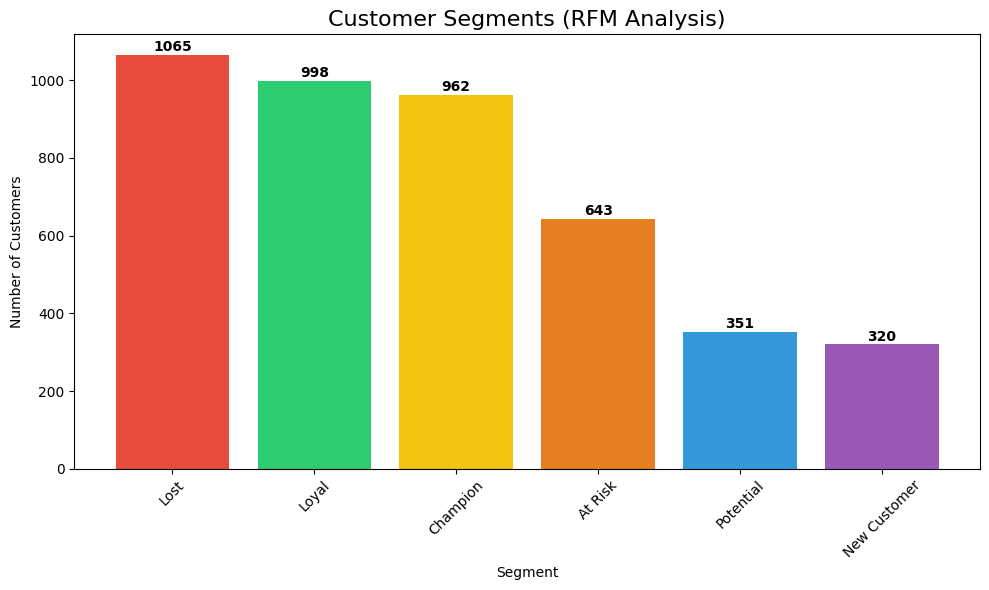

In [ ]:
import matplotlib.pyplot as plt

segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10,6))
colors = ['#e74c3c','#2ecc71','#f1c40f','#e67e22','#3498db','#9b59b6']
plt.bar(segment_counts.index, segment_counts.values, color=colors)
plt.title('Customer Segments (RFM Analysis)', fontsize=16)
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
for i, v in enumerate(segment_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('customer_segments.png', dpi=150)
plt.show()

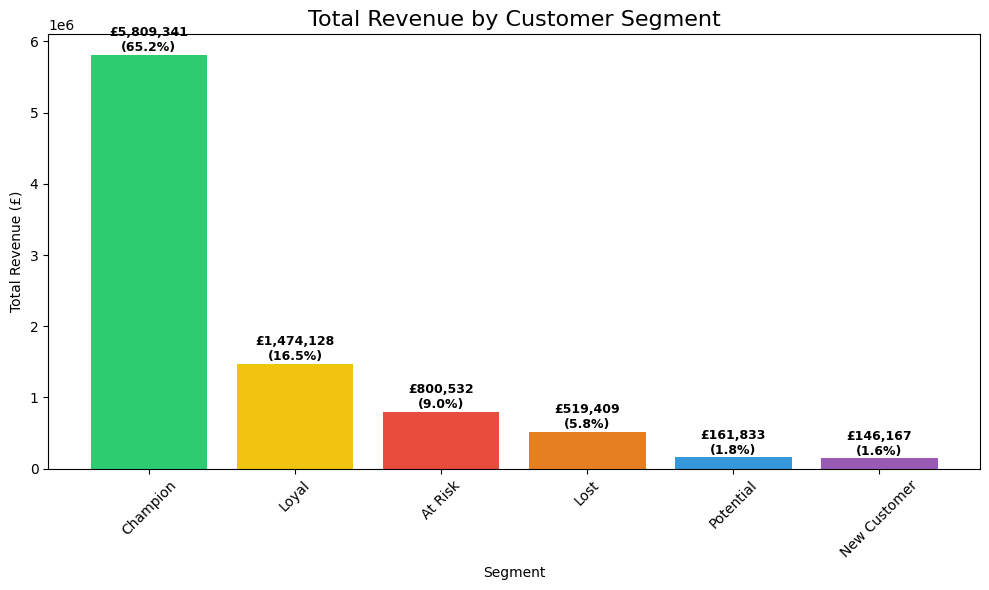

Segment
Champion        65.2
Loyal           16.5
At Risk          9.0
Lost             5.8
Potential        1.8
New Customer     1.6
Name: Monetary, dtype: float64


In [ ]:
# Revenue by segment
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
segment_revenue_pct = (segment_revenue / segment_revenue.sum() * 100).round(1)

plt.figure(figsize=(10,6))
colors = ['#2ecc71','#f1c40f','#e74c3c','#e67e22','#3498db','#9b59b6']
bars = plt.bar(segment_revenue.index, segment_revenue.values, color=colors)
plt.title('Total Revenue by Customer Segment', fontsize=16)
plt.xlabel('Segment')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
for i, (v, pct) in enumerate(zip(segment_revenue.values, segment_revenue_pct.values)):
    plt.text(i, v + 50000, f'£{v:,.0f}\n({pct}%)', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('revenue_by_segment.png', dpi=150)
plt.show()

print(segment_revenue_pct)

## Key Findings
- Champions (22% of customers) generate 65.2% of total revenue (£5.8M)
- 643 At Risk customers represent £800,532 in revenue at immediate risk
- 1,065 Lost customers — the largest segment by count
- Only 320 new customers (7%) — acquisition funnel is weak
- Average customer bought 4.27 times and spent £2,053 total

## Business Recommendations

**1. Launch a win-back campaign for At Risk customers (immediate priority)**
643 customers representing £800,532 are showing early churn signals —
they used to buy frequently but haven't returned recently.
Recommended action: personalised email campaign with a time-limited
discount (10-15%) within the next 30 days. Even recovering 30% of these
customers would retain ~£240,000 in revenue.

**2. Protect the Champion base with a VIP programme**
962 customers generate 65% of all revenue (£5.8M). Losing even 10% of
Champions would cost £580,000.
Recommended action: introduce a VIP tier — early access to new products,
free shipping, exclusive offers. Cost is low; risk of not doing it is enormous.

**3. Launch a referral programme targeting Champions**
New customers are only 7% of the base — acquisition is weak. Champions
already love the product and have high trust.
Recommended action: incentivise Champions to refer friends with store
credit or discounts. Referral programmes convert at 3-5x higher than
cold acquisition channels.

**4. Investigate why 1,065 customers are Lost**
Before spending on re-acquisition, understand why they left.
Recommended action: analyse Lost customers' last purchases — was it
price, product quality, or a bad experience? Fix the root cause
before spending budget on win-back campaigns.

**5. Improve new customer onboarding**
Only 320 new customers signals weak acquisition. New customers need
a strong first experience to become Loyal or Champion.
Recommended action: introduce a welcome sequence — first purchase
discount, product recommendations, follow-up at day 7 and day 30.
